1) Data Cleaning

In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [92]:
df=pd.read_csv('netflix_titles.csv',encoding='latin1')
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [93]:
df.shape

(8807, 12)

In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [95]:
df['country'].unique()

array(['United States', 'South Africa', nan, 'India',
       'United States, Ghana, Burkina Faso, United Kingdom, Germany, Ethiopia',
       'United Kingdom', 'Germany, Czech Republic', 'Mexico', 'Turkey',
       'Australia', 'United States, India, France', 'Finland',
       'China, Canada, United States',
       'South Africa, United States, Japan', 'Nigeria', 'Japan',
       'Spain, United States', 'France', 'Belgium',
       'United Kingdom, United States', 'United States, United Kingdom',
       'France, United States', 'South Korea', 'Spain',
       'United States, Singapore', 'United Kingdom, Australia, France',
       'United Kingdom, Australia, France, United States',
       'United States, Canada', 'Germany, United States',
       'South Africa, United States', 'United States, Mexico',
       'United States, Italy, France, Japan',
       'United States, Italy, Romania, United Kingdom',
       'Australia, United States', 'Argentina, Venezuela',
       'United States, United Kin

In [96]:
df['rating'].unique()

array(['PG-13', 'TV-MA', 'PG', 'TV-14', 'TV-PG', 'TV-Y', 'TV-Y7', 'R',
       'TV-G', 'G', 'NC-17', '74 min', '84 min', '66 min', 'NR', nan,
       'TV-Y7-FV', 'UR'], dtype=object)

In [97]:
df['type'].unique()

array(['Movie', 'TV Show'], dtype=object)

In [98]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [99]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [100]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [101]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [102]:
df['director']=df['director'].fillna(df['director'].mode()[0])
df['cast']=df['cast'].fillna(df['cast'].mode()[0])
df['country']=df['country'].fillna(df['country'].mode()[0])
df['date_added']=df['date_added'].fillna(df['date_added'].mode()[0])
df['rating']=df['rating'].fillna(df['rating'].mode()[0])
df['duration']=df['duration'].fillna(df['duration'].mode()[0])

In [103]:
df.isna().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


In [104]:
df.duplicated().sum()

np.int64(0)

2) Data Visualization

In [105]:
import warnings
warnings.filterwarnings('ignore')

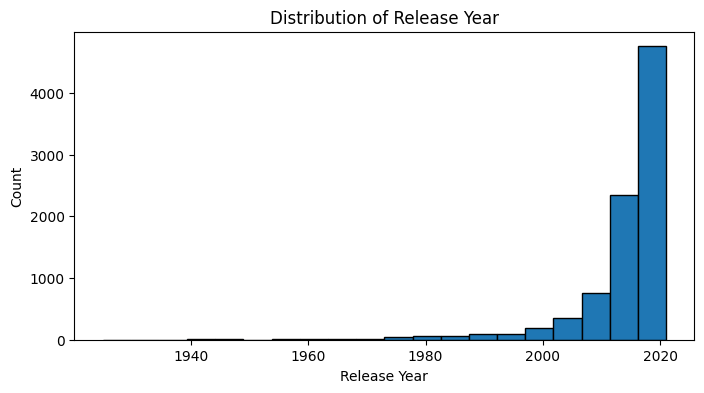

In [106]:
plt.figure(figsize=(8, 4))
plt.hist(df['release_year'], bins=20, edgecolor='black')
plt.title('Distribution of Release Year')
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.show()

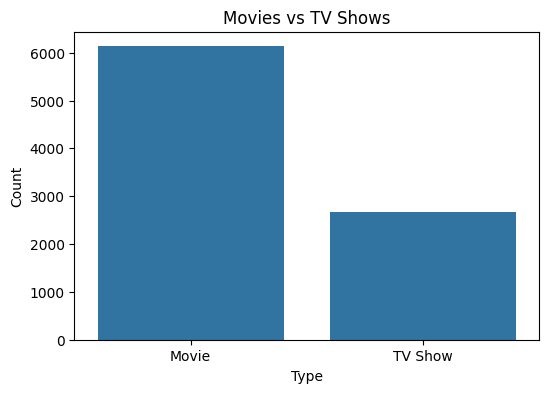

In [107]:
plt.figure(figsize=(6, 4))
sns.countplot(x=df['type'])
plt.title('Movies vs TV Shows')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

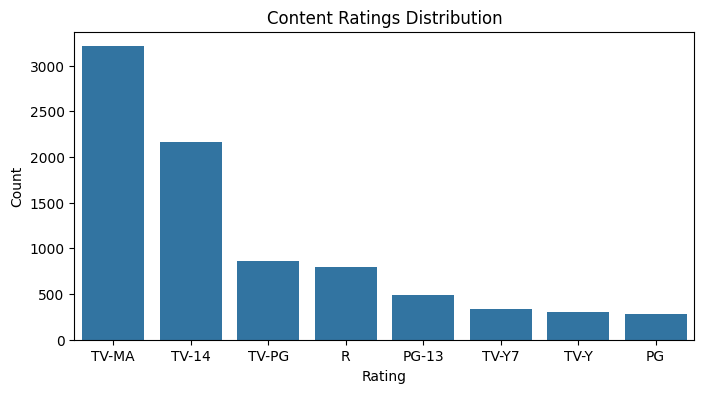

In [108]:
plt.figure(figsize=(8, 4))
top_ratings = df['rating'].value_counts().nlargest(8).index
sns.countplot(
    x=df[df['rating'].isin(top_ratings)]['rating'], order=top_ratings
)
plt.title('Content Ratings Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

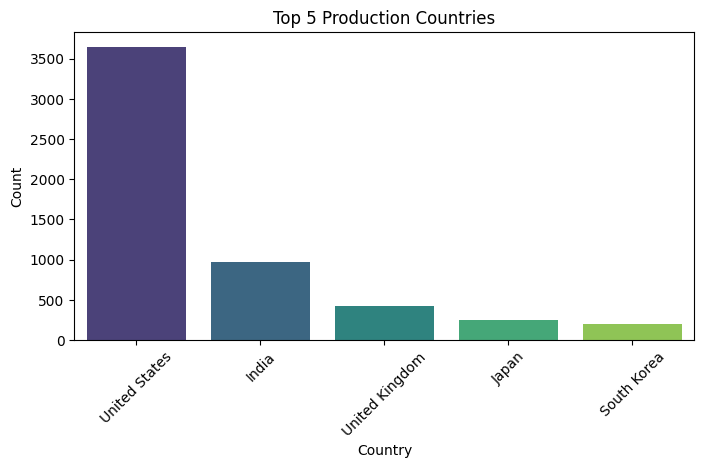

In [109]:
plt.figure(figsize=(8, 4))
top_countries = df['country'].value_counts().nlargest(5).index
sns.countplot(
    x=df[df['country'].isin(top_countries)]['country'],
    order=top_countries,
    hue=df[df['country'].isin(top_countries)]['country'],
    palette='viridis',
    legend=False,
)
plt.title('Top 5 Production Countries')
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

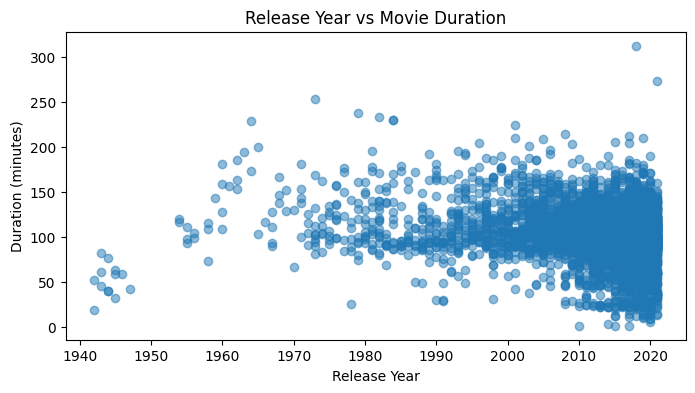

np.float64(-0.2058238932074605)

In [110]:
df_movies = df[df['type'] == 'Movie'].copy()

df_movies['duration_num'] = pd.to_numeric(
    df_movies['duration'].str.extract('(\d+)')[0], errors='coerce'
)

plt.figure(figsize=(8, 4))
plt.scatter(df_movies['release_year'], df_movies['duration_num'], alpha=0.5)
plt.title('Release Year vs Movie Duration')
plt.xlabel('Release Year')
plt.ylabel('Duration (minutes)')
plt.show()


df_movies['release_year'].corr(df_movies['duration_num'])

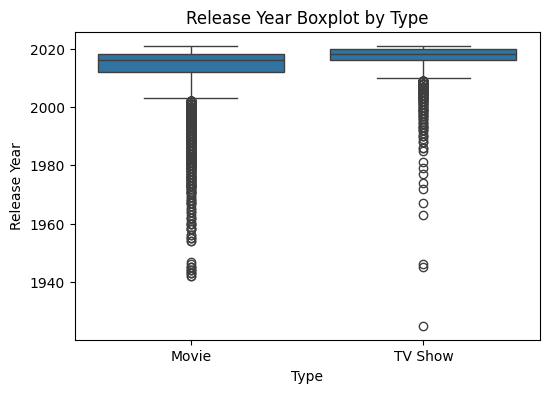

In [111]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=df['type'], y=df['release_year'])
plt.title('Release Year Boxplot by Type')
plt.xlabel('Type')
plt.ylabel('Release Year')
plt.show()

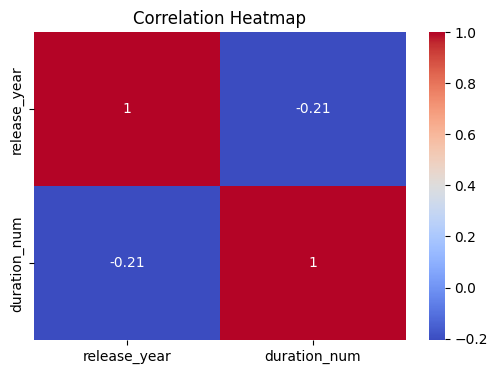

In [112]:
plt.figure(figsize=(6, 4))
sns.heatmap(
    df_movies[['release_year', 'duration_num']].corr(),
    annot=True,
    cmap='coolwarm',
)
plt.title('Correlation Heatmap')
plt.show()

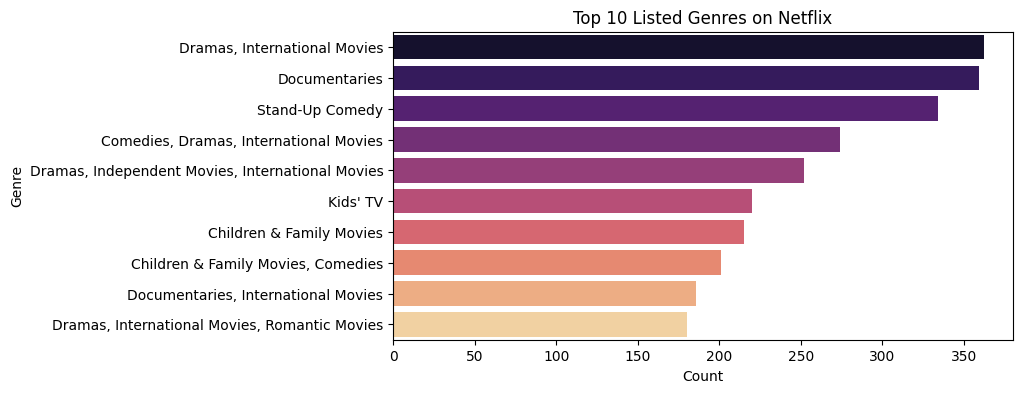

In [113]:
import pandas as pd
df_genres = pd.read_csv('netflix_titles.csv', encoding='latin1')

plt.figure(figsize=(8, 4))
top_genres = df_genres['listed_in'].value_counts().nlargest(10)
sns.barplot(x=top_genres.values, y=top_genres.index, palette='magma')
plt.title('Top 10 Listed Genres on Netflix')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.show()

3) Classification

In [114]:
df=pd.read_csv('netflix_titles.csv')

In [115]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [116]:
df=df.drop(['show_id','title','description','date_added','director','cast'],axis=1)
df

,type,country,release_year,rating,duration,listed_in
0,Movie,United States,2020,PG-13,90 min,Documentaries
1,TV Show,South Africa,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries"
2,TV Show,NaN,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
3,TV Show,NaN,2021,TV-MA,1 Season,"Docuseries, Reality TV"
4,TV Show,India,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ..."
...,...,...,...,...,...,...
8802,Movie,United States,2007,R,158 min,"Cult Movies, Dramas, Thrillers"
8803,TV Show,NaN,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies"
8804,Movie,United States,2009,R,88 min,"Comedies, Horror Movies"
8805,Movie,United States,2006,PG,88 min,"Children & Family Movies, Comedies"


In [117]:
df=df.dropna()
df

,type,country,release_year,rating,duration,listed_in
0,Movie,United States,2020,PG-13,90 min,Documentaries
1,TV Show,South Africa,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries"
4,TV Show,India,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ..."
7,Movie,"United States, Ghana, Burkina Faso, United Kin...",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"
8,TV Show,United Kingdom,2021,TV-14,9 Seasons,"British TV Shows, Reality TV"
...,...,...,...,...,...,...
8801,Movie,"United Arab Emirates, Jordan",2015,TV-MA,96 min,"Dramas, International Movies, Thrillers"
8802,Movie,United States,2007,R,158 min,"Cult Movies, Dramas, Thrillers"
8804,Movie,United States,2009,R,88 min,"Comedies, Horror Movies"
8805,Movie,United States,2006,PG,88 min,"Children & Family Movies, Comedies"


In [118]:
df = pd.get_dummies(df, columns=['rating','country','listed_in','duration'])
df

,type,release_year,rating_G,rating_NC-17,rating_NR,rating_PG,rating_PG-13,rating_R,rating_TV-14,rating_TV-G,...,duration_90 min,duration_91 min,duration_92 min,duration_93 min,duration_94 min,duration_95 min,duration_96 min,duration_97 min,duration_98 min,duration_99 min
0,Movie,2020,False,False,False,False,True,False,False,False,...,True,False,False,False,False,False,False,False,False,False
1,TV Show,2021,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,TV Show,2021,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7,Movie,1993,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
8,TV Show,2021,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8801,Movie,2015,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
8802,Movie,2007,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
8804,Movie,2009,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
8805,Movie,2006,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [119]:
x=df.drop('type',axis=1).values
y=df['type'].values

In [120]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [121]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(x_train,y_train)

LogisticRegression()

In [122]:
prediction=model.predict(x_test)

In [123]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,prediction)

0.9962358845671268

4) Regression

In [124]:
df["type"] = df["type"].map({
    "Movie": 0,
    "TV Show": 1
})

In [125]:
df = pd.read_csv('netflix_titles.csv', encoding='latin1')

df['director']=df['director'].fillna(df['director'].mode()[0])
df['cast']=df['cast'].fillna(df['cast'].mode()[0])
df['country']=df['country'].fillna(df['country'].mode()[0])
df['date_added']=df['date_added'].fillna(df['date_added'].mode()[0])
df['rating']=df['rating'].fillna(df['rating'].mode()[0])
df['duration']=df['duration'].fillna(df['duration'].mode()[0])

df["type"] = df["type"].map({
    "Movie": 0,
    "TV Show": 1
})

df["date_added"] = pd.to_datetime(df["date_added"], format='mixed')
df["added_year"] = df["date_added"].dt.year
df["years_until_added"] = (
    df["added_year"] -
    df["release_year"]
)

In [126]:
df["genre_count"] = df["listed_in"].str.split(",").str.len()

In [127]:
df["director_count"] = (
    df["director"]
      .fillna("")
      .str.split(",")
      .str.len()
)

In [128]:
df["cast_size"] = df.loc[:, "cast"].str.split(",").str.len()

In [129]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,added_year,years_until_added,genre_count,director_count,cast_size
0,s1,0,Dick Johnson Is Dead,Kirsten Johnson,David Attenborough,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,1,1,1,1
1,s2,1,Blood & Water,Rajiv Chilaka,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,0,3,1,19
2,s3,1,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,0,3,1,9
3,s4,1,Jailbirds New Orleans,Rajiv Chilaka,David Attenborough,United States,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021,0,2,1,1
4,s5,1,Kota Factory,Rajiv Chilaka,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,0,3,1,8


In [130]:
df = df[df["type"] == 0]

In [131]:
X =df[
    [
        "release_year",
        "genre_count",
        "director_count",
        "cast_size"
    ]
].values

In [132]:
y = df["years_until_added"].values

In [133]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [134]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression()

In [135]:
predicted_y= regressor.predict(X_test)
print(predicted_y)

[ 3.88651781 -1.7797492   8.51648945 ...  0.94361101 -2.25108107
  9.82227704]


In [136]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, predicted_y)

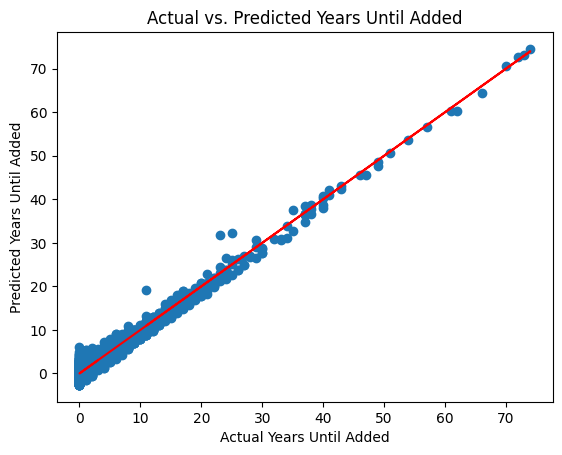

In [137]:
plt.scatter(y_test, predicted_y)
plt.plot(y_test, y_test, color='red')
plt.xlabel("Actual Years Until Added")
plt.ylabel("Predicted Years Until Added")
plt.title("Actual vs. Predicted Years Until Added")
plt.show()

In [138]:
print("R² Score:", r2)

R² Score: 0.976659829385664
